In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv("Admission_Predict.csv")

from sklearn.preprocessing import Binarizer
limit = Binarizer(threshold=0.75)
data["Chance of Admit "] = limit.fit_transform(data[["Chance of Admit "]])
print(data)

     Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0             1        337          118                  4  4.5   4.5  9.65   
1             2        324          107                  4  4.0   4.5  8.87   
2             3        316          104                  3  3.0   3.5  8.00   
3             4        322          110                  3  3.5   2.5  8.67   
4             5        314          103                  2  2.0   3.0  8.21   
..          ...        ...          ...                ...  ...   ...   ...   
395         396        324          110                  3  3.5   3.5  9.04   
396         397        325          107                  3  3.0   3.5  9.11   
397         398        330          116                  4  5.0   4.5  9.45   
398         399        312          103                  3  3.5   4.0  8.78   
399         400        333          117                  4  5.0   4.0  9.66   

     Research  Chance of Admit   
0           1    

In [13]:
inputdata = data.drop(["Chance of Admit "], axis=1)
outputdata = data[["Chance of Admit "]]
print(inputdata)

     Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0             1        337          118                  4  4.5   4.5  9.65   
1             2        324          107                  4  4.0   4.5  8.87   
2             3        316          104                  3  3.0   3.5  8.00   
3             4        322          110                  3  3.5   2.5  8.67   
4             5        314          103                  2  2.0   3.0  8.21   
..          ...        ...          ...                ...  ...   ...   ...   
395         396        324          110                  3  3.5   3.5  9.04   
396         397        325          107                  3  3.0   3.5  9.11   
397         398        330          116                  4  5.0   4.5  9.45   
398         399        312          103                  3  3.5   4.0  8.78   
399         400        333          117                  4  5.0   4.0  9.66   

     Research  
0           1  
1           1  
2  

In [14]:
print(outputdata)

     Chance of Admit 
0                 1.0
1                 1.0
2                 0.0
3                 1.0
4                 0.0
..                ...
395               1.0
396               1.0
397               1.0
398               0.0
399               1.0

[400 rows x 1 columns]


In [15]:
outputdata = outputdata.astype(int)
print(outputdata)

     Chance of Admit 
0                   1
1                   1
2                   0
3                   1
4                   0
..                ...
395                 1
396                 1
397                 1
398                 0
399                 1

[400 rows x 1 columns]


In [20]:
x_train, x_test, y_train, y_test = train_test_split(
    inputdata, outputdata, test_size=0.25, random_state=0
)
print("✅ Training and testing split successful!")
print("Training set shape:", x_train.shape)
print("Testing set shape:", x_test.shape)

✅ Training and testing split successful!
Training set shape: (300, 8)
Testing set shape: (100, 8)


In [24]:
model = DecisionTreeClassifier(criterion='entropy', random_state=0)
model.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [25]:
y_pred = model.predict(x_test)


In [28]:
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)
print("\n✅ Model Evaluation:")
print("Accuracy:", accuracy*100, "%")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)




✅ Model Evaluation:
Accuracy: 86.0 %

Confusion Matrix:
 [[53  6]
 [ 8 33]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.90      0.88        59
           1       0.85      0.80      0.82        41

    accuracy                           0.86       100
   macro avg       0.86      0.85      0.85       100
weighted avg       0.86      0.86      0.86       100



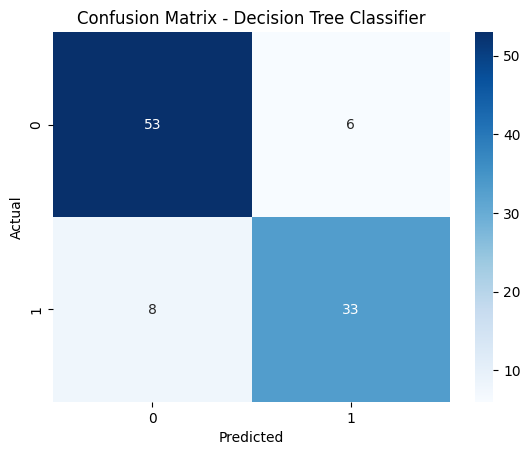

In [29]:
# Step 11: Visualize Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()